In [1]:
from matplotlib import pyplot as plot
from scipy.spatial import KDTree
import numpy as np 
import pandas as pd 
import os
print(os.getcwd())

import sys
sys.path.append("..")

from utils.animation import custom_n_colormap

/vast/palmer/home.grace/kd766/quorum-sensing/notebooks


In [2]:
import matplotlib as mpl
mpl.rcParams['font.size'] = 10  # Default font size for general text
mpl.rcParams['axes.labelsize'] = 11 # Font size for axis labels
mpl.rcParams['xtick.labelsize'] = 9 # Font size for x-axis tick labels
mpl.rcParams['ytick.labelsize'] = 9 # Font size for y-axis tick labels
mpl.rcParams['legend.fontsize'] = 9 # Font size for legend
mpl.rcParams['axes.titlesize'] = 11 # Font size for plot title

In [13]:
def _old_slide_window(mat, r=10):
	"""
	previous method, sliding a constant window over the entire array
	"""
	windows = np.lib.stride_tricks.sliding_window_view(mat, window_shape=(r, r))
	means_l = []
	stdevs_l = []
	n_cells_l = [] 
	# print(mat.shape, windows.shape)
	for win_row in windows:
		for win in win_row:
			vals = win[np.nonzero(win)].flatten()
			n_cells_l.append(len(vals))
			means_l.append(np.mean(vals))
			stdevs_l.append(np.std(vals))
	return means_l, stdevs_l, n_cells_l


def slide_window(mat, ref_mat, neighbor_thresh=10):
	"""
	go cell-to-cell and find neighbors, instead of sliding the window everywhere
	- neighbor_thresh: how far another cell can be to be considered a neighbor.
	"""
	assert mat.shape==ref_mat.shape, "matrix and ref. matrix should have the same shape."
	
	# stats to collect.
	means_l = []
	stdevs_l = []
	n_cells_l = [] 
	# locate positions of cells.
	cell_posns = np.nonzero(ref_mat)
	# iteration helpers.
	r = neighbor_thresh		# shorthand.
	x_max, y_max = [dim-1 for dim in mat.shape]
	windows_l = []
	for posn_x, posn_y in zip(*cell_posns):
		# get window -- region of interest.
		top, bottom = max(0, posn_x-r), min(x_max, posn_x+r)	# rows.
		left, right = max(0, posn_y-r), min(y_max, posn_y+r)	# cols.
		mat_window = mat[top:bottom+1, left:right+1]
		ref_mat_window = ref_mat[top:bottom+1, left:right+1]
		# find locations of cells, and pick the values at those positions.
		vals = mat_window[np.nonzero(ref_mat_window)].flatten()
		# store stats.
		n_cells_l.append(len(vals))
		means_l.append(np.mean(vals))
		stdevs_l.append(np.std(vals))
		windows_l.append(((left, top), right-left, bottom-top))

	# return stats.
	return (means_l, stdevs_l, n_cells_l)


def slide_window_using_tree(mat, ref_mat, n_neighbors=10):

	assert mat.shape==ref_mat.shape, "matrix and ref. matrix should have the same shape."
	
	# construct a KD tree of cell positions.
	cell_posns = np.array(tuple(zip(*np.nonzero(ref_mat))))
	tree = KDTree(cell_posns)
	# include the cell itself at index 0.
	dists, indices = tree.query(cell_posns, k=n_neighbors+1) 
	# find the enclosing areas on the matrix.
	window_minmax_coords = [(np.min(np.squeeze(arr), axis=1), np.max(np.squeeze(arr), axis=1)) 
		for arr in np.split(np.array(cell_posns[indices]), 2, axis=-1)]
	# collect stats for all neighborhoods.
	means_l = []
	stdevs_l = []
	for (min_x, max_x, min_y, max_y) in zip(*(window_minmax_coords[0] + window_minmax_coords[1])):
		mat_window = mat[min_x:max_x+1, min_y:max_y+1]
		ref_mat_window = ref_mat[min_x:max_x+1, min_y:max_y+1]
		# find locations of cells, and pick the values at those positions.
		# vals = mat_window[np.nonzero(ref_mat_window)].flatten()
		vals = mat_window.flatten()		# use all posns; not just where cells are.
		# store stats.
		means_l.append(np.mean(vals, where=(vals!=0)))		# compute using non-zero values only.
		stdevs_l.append(np.std(vals, where=(vals!=0)))		# compute using non-zero values only.
	
	## older method that simply uses the cell posns.
	# for i in range(len(cell_posns)):
	# 	# exclude self.
	# 	neighbor_signals = mat[cell_posns[indices[i][1:]]] 
	# 	# compute stats.
	# 	mu = np.mean(neighbor_signals)
	# 	sigma = np.std(neighbor_signals)
	# 	# accumulate stats.
	# 	means_l.append(mu)
	# 	stdevs_l.append(sigma)

	return (means_l, stdevs_l, n_neighbors)

In [36]:
# file names of `clouds` file is extrapolated based on these file paths as well.
levels_withneg_l = [
	# "/home/kd766/quorum-sensing/outputs/04112025064926_size-100x100_select-0.3_seed-0.025/04112025064926_size-100x100_select-0.3_seed-0.025_levels_all.npy",
	# "/home/kd766/quorum-sensing/outputs/06262025214226_size-100x100_select-0.8_seed-0.03/06262025214226_size-100x100_select-0.8_seed-0.03_levels_all.npy",
	# "/home/kd766/quorum-sensing/outputs/04112025064724_size-100x100_select-0.3_seed-0.0333/04112025064724_size-100x100_select-0.3_seed-0.0333_levels_all.npy",
	# "/home/kd766/quorum-sensing/outputs/06262025214211_size-100x100_select-0.8_seed-0.05/06262025214211_size-100x100_select-0.8_seed-0.05_levels_all.npy",
	# "/home/kd766/quorum-sensing/outputs/05292025212917_size-100x100_select-1_seed-0.0667/05292025212917_size-100x100_select-1_seed-0.0667_levels_all.npy",
	# "/home/kd766/quorum-sensing/outputs/05292025180028_size-100x100_select-0.3_seed-0.1/05292025180028_size-100x100_select-0.3_seed-0.1_levels_all.npy",
	# "/home/kd766/quorum-sensing/outputs/05292025180016_size-100x100_select-0.3_seed-0.125/05292025180016_size-100x100_select-0.3_seed-0.125_levels_all.npy",
	# "/home/kd766/quorum-sensing/outputs/05292025174657_size-100x100_select-0.4_seed-0.15/05292025174657_size-100x100_select-0.4_seed-0.15_levels_all.npy",
	# "/home/kd766/quorum-sensing/outputs/05292025180030_size-100x100_select-0.3_seed-0.175/05292025180030_size-100x100_select-0.3_seed-0.175_levels_all.npy",
	# "/home/kd766/quorum-sensing/outputs/05292025180015_size-100x100_select-0.3_seed-0.2/05292025180015_size-100x100_select-0.3_seed-0.2_levels_all.npy",
	# "/home/kd766/quorum-sensing/outputs/06262025142707_size-100x100_select-0.3_seed-0.225/06262025142707_size-100x100_select-0.3_seed-0.225_levels_all.npy",
	# "/home/kd766/quorum-sensing/outputs/06262025142751_size-100x100_select-0.3_seed-0.25/06262025142751_size-100x100_select-0.3_seed-0.25_levels_all.npy",
	# "/home/kd766/quorum-sensing/outputs/06262025142714_size-100x100_select-0.3_seed-0.275/06262025142714_size-100x100_select-0.3_seed-0.275_levels_all.npy",
 #    "/home/kd766/quorum-sensing/outputs/12072025064439_size-100x100_select-0.4_seed-0.3/12072025064439_size-100x100_select-0.4_seed-0.3_levels_all.npy",
 #    "/home/kd766/quorum-sensing/outputs/12072025064652_size-100x100_select-0.4_seed-0.325/12072025064652_size-100x100_select-0.4_seed-0.325_levels_all.npy",
    "/home/kd766/quorum-sensing/outputs/12072025064721_size-100x100_select-0.4_seed-0.35/12072025064721_size-100x100_select-0.4_seed-0.35_levels_all.npy",
    # "/home/kd766/quorum-sensing/outputs/12072025064721_size-100x100_select-0.4_seed-0.375/12072025064721_size-100x100_select-0.4_seed-0.375_levels_all.npy",
    # "/home/kd766/quorum-sensing/outputs/12072025071240_size-100x100_select-0.4_seed-0.4/12072025071240_size-100x100_select-0.4_seed-0.4_levels_all.npy",
]

levels_noneg_l = [
	# "/home/kd766/quorum-sensing/outputs/07232025152722_size-100x100_select-0.3_seed-0.025_noneg/07232025152722_size-100x100_select-0.3_seed-0.025_noneg_levels_all.npy",
	# "/home/kd766/quorum-sensing/outputs/07232025162644_size-100x100_select-0.3_seed-0.03_noneg/07232025162644_size-100x100_select-0.3_seed-0.03_noneg_levels_all.npy",
	# "/home/kd766/quorum-sensing/outputs/07232025152745_size-100x100_select-0.3_seed-0.0333_noneg/07232025152745_size-100x100_select-0.3_seed-0.0333_noneg_levels_all.npy",
	# "/home/kd766/quorum-sensing/outputs/07232025162614_size-100x100_select-0.3_seed-0.05_noneg/07232025162614_size-100x100_select-0.3_seed-0.05_noneg_levels_all.npy",
	# "/home/kd766/quorum-sensing/outputs/07232025152552_size-100x100_select-0.3_seed-0.0667_noneg/07232025152552_size-100x100_select-0.3_seed-0.0667_noneg_levels_all.npy",
	# "/home/kd766/quorum-sensing/outputs/07232025152554_size-100x100_select-0.3_seed-0.1_noneg/07232025152554_size-100x100_select-0.3_seed-0.1_noneg_levels_all.npy",
	# "/home/kd766/quorum-sensing/outputs/07232025152556_size-100x100_select-0.3_seed-0.125_noneg/07232025152556_size-100x100_select-0.3_seed-0.125_noneg_levels_all.npy",
	# "/home/kd766/quorum-sensing/outputs/07232025152621_size-100x100_select-0.3_seed-0.15_noneg/07232025152621_size-100x100_select-0.3_seed-0.15_noneg_levels_all.npy",
	# "/home/kd766/quorum-sensing/outputs/07232025152648_size-100x100_select-0.3_seed-0.175_noneg/07232025152648_size-100x100_select-0.3_seed-0.175_noneg_levels_all.npy",
	# "/home/kd766/quorum-sensing/outputs/07232025152708_size-100x100_select-0.3_seed-0.2_noneg/07232025152708_size-100x100_select-0.3_seed-0.2_noneg_levels_all.npy",
	# "/home/kd766/quorum-sensing/outputs/07232025164017_size-100x100_select-0.3_seed-0.225_noneg/07232025164017_size-100x100_select-0.3_seed-0.225_noneg_levels_all.npy",
	# "/home/kd766/quorum-sensing/outputs/07232025164023_size-100x100_select-0.3_seed-0.25_noneg/07232025164023_size-100x100_select-0.3_seed-0.25_noneg_levels_all.npy",
	# "/home/kd766/quorum-sensing/outputs/07232025164056_size-100x100_select-0.3_seed-0.275_noneg/07232025164056_size-100x100_select-0.3_seed-0.275_noneg_levels_all.npy",
 #    "/home/kd766/quorum-sensing/outputs/12072025070551_size-100x100_select-0.4_seed-0.3_noneg/12072025070551_size-100x100_select-0.4_seed-0.3_noneg_levels_all.npy",
 #    "/home/kd766/quorum-sensing/outputs/12072025070551_size-100x100_select-0.4_seed-0.325_noneg/12072025070551_size-100x100_select-0.4_seed-0.325_noneg_levels_all.npy",
    "/home/kd766/quorum-sensing/outputs/12072025070551_size-100x100_select-0.4_seed-0.35_noneg/12072025070551_size-100x100_select-0.4_seed-0.35_noneg_levels_all.npy",
    # "/home/kd766/quorum-sensing/outputs/12072025070528_size-100x100_select-0.4_seed-0.375_noneg/12072025070528_size-100x100_select-0.4_seed-0.375_noneg_levels_all.npy",
    # "/home/kd766/quorum-sensing/outputs/12072025071216_size-100x100_select-0.4_seed-0.4_noneg/12072025071216_size-100x100_select-0.4_seed-0.4_noneg_levels_all.npy",
]

In [ ]:
# timepoints at which to analyze each of the above experiments; one set per setup.
timepoints_mat = [
	# [x for x in range(1, 49, 5)],  		# 0.025
	# [x for x in range(1, 49, 5)],		# 0.033
	# [x for x in range(1, 49, 4)],		# 0.0667
	# [x for x in range(1, 49, 4)],		# 0.0667
	# [x for x in range(1, 49, 4)],		# 0.0667
	[x for x in range(1, 49, 2)],		# 0.0667
	[x for x in range(1, 49, 2)],		# 0.0667
	[x for x in range(1, 49, 2)],		# 0.0667
]

for feedback_str in ["", "noneg"]:

    # pick levels matrix accordingly.
    levels_l = levels_noneg_l if feedback_str=="noneg" else levels_withneg_l
    
    # set the reqd. cells per window range -- window size will be scaled based on density.
    for levels_fpath, timepoints_l in zip(levels_l, timepoints_mat):
        
        # infer simulation config.
        dirpath, fname = os.path.split(levels_fpath)
        clouds_fpath = os.path.join(dirpath, '_'.join(fname.split('_')[:-2]) + '_clouds_all.npy')
        seeding_density_str = fname.split('_')[3].split('-')[-1]
        seeding_density = round(float(seeding_density_str), 4)
        
        # read files.
        levels = np.load(levels_fpath)
        clouds = np.load(clouds_fpath)
    
        # compute window/neighborhood size range.
        neighborhood_range = [28]
        print(neighborhood_range)
        
        # run sliding window on levels and clouds.
        levels_fig = plot.figure(figsize=(16, 12))
        clouds_fig = plot.figure(figsize=(16, 12))
        for idx, r in enumerate(neighborhood_range):
            
            # levels.
            plot.figure(levels_fig)
            ax = plot.subplot(1, len(neighborhood_range)//2+1, idx+1)
            for tpoint_idx, tpoint in enumerate(timepoints_l):
                means_l, stdevs_l, n_cells_l = slide_window_using_tree(
                    mat=levels[tpoint, :, :], ref_mat=levels[tpoint, :, :], n_neighbors=r)
                levels_plot = ax.scatter(means_l, stdevs_l, s=0.9, cmap=custom_n_colormap(n=4),
                    c=[tpoint]*len(means_l), vmin=min(timepoints_l), vmax=max(timepoints_l),
                    label=f"t={tpoint}", alpha=0.5)
            # enforce a square plot area
            ax.set_box_aspect(1) 
            ax.set_xlabel("mean signal")
            ax.set_ylabel("std dev. signal")
            ax.set_title(f"# cells / window = {round(np.mean(n_cells_l), 2)}")
            
            # clouds.
            plot.figure(clouds_fig)
            ax = plot.subplot(1, len(neighborhood_range)//2+1, idx+1)
            for tpoint_idx, tpoint in enumerate(timepoints_l):
                means_l, stdevs_l, n_cells_l = slide_window_using_tree(
                    mat=clouds[tpoint, :, :], ref_mat=levels[tpoint, :, :], n_neighbors=r)
                cloud_plot = ax.scatter(means_l, stdevs_l, s=0.9, cmap=custom_n_colormap(n=4),
                    c=[tpoint]*len(means_l), vmin=min(timepoints_l), vmax=max(timepoints_l),
                    label=f"t={tpoint}", alpha=0.5)
            # enforce a square plot area
            ax.set_box_aspect(1) 
            ax.set_xlabel("mean cloud")
            ax.set_ylabel("std dev. cloud")
            ax.set_title(f"# cells / window = {round(np.mean(n_cells_l), 2)}")
        
        # save the figures.
        plot.figure(levels_fig)
        # plot.legend()
        plot.colorbar(levels_plot)
        plot.suptitle(f"signaling intensity at density={seeding_density*100}%")
        plot.close()
        
        plot.figure(clouds_fig)
        # plot.legend()
        plot.colorbar(cloud_plot)
        plot.suptitle(f"cloud intensity at density={seeding_density*100}%")
        plot.close()
    
        plot.figure(clouds_fig)
        plot.show()
        plot.figure(levels_fig)
        # plot.show()

In [50]:
def plot_local_trends(feedback_str, levels_overlay_fig, cloud_overlay_fig, n_neighbors):
        
    levels_ax = levels_overlay_fig.gca()
    cloud_ax = cloud_overlay_fig.gca() 
    
    levels_l = levels_noneg_l if feedback_str=="noneg" else levels_withneg_l

    cloud_overlay_idx = 0
    levels_overlay_idx = 0
    for density_idx, levels_fpath in enumerate(levels_l):
        
        # infer simulation config.
        dirpath, fname = os.path.split(levels_fpath)
        clouds_fpath = os.path.join(dirpath, '_'.join(fname.split('_')[:-2]) + '_clouds_all.npy')
        seeding_density_str = fname.split('_')[3].split('-')[-1]
        seeding_density = round(float(seeding_density_str), 4)
        
        # read files.
        levels = np.load(levels_fpath)
        clouds = np.load(clouds_fpath)
        
        # run sliding window on levels and clouds.
        levels_overlayed = False
        cloud_overlayed = False 
    
        # levels.
        ax = levels_ax
        for tpoint_idx, tpoint in enumerate(timepoints_l):
            means_l, stdevs_l, n_cells_l = slide_window_using_tree(
                mat=levels[tpoint, :, :], ref_mat=levels[tpoint, :, :], n_neighbors=n_neighbors)
            levels_plot = ax.scatter(means_l, stdevs_l, s=0.9, cmap=custom_n_colormap(n=4),
                c=[tpoint]*len(means_l), vmin=min(timepoints_l), vmax=max(timepoints_l),
                label=f"t={tpoint}", alpha=0.4)
        # enforce a square plot area
        ax.set_box_aspect(1) 
        ax.set_xlabel("Mean Local TNF Secretion (a.u.)")
        ax.set_ylabel("Std Dev. Local TNF Secretion (a.u.)")
        
        # clouds.
        ax = cloud_ax
        for tpoint_idx, tpoint in enumerate(timepoints_l):
            means_l, stdevs_l, n_cells_l = slide_window_using_tree(
                mat=clouds[tpoint, :, :], ref_mat=levels[tpoint, :, :], n_neighbors=n_neighbors)
            cloud_plot = ax.scatter(means_l, stdevs_l, s=0.9, cmap=custom_n_colormap(n=4),
                c=[tpoint]*len(means_l), vmin=min(timepoints_l), vmax=max(timepoints_l),
                label=f"t={tpoint}", alpha=0.4)
        # enforce a square plot area
        ax.set_box_aspect(1) 
        ax.set_xlabel("Mean Local Cloud Intensity (a.u.)")
        ax.set_ylabel("Std Dev. Local Cloud Intensity (a.u.)")

    plot.figure(levels_overlay_fig)
    plot.colorbar(levels_plot, label="Simulation Time", location='right')
    levels_ax.set_xlim([0, 10])
    levels_ax.set_ylim([-0.1, 3])
    
    plot.figure(cloud_overlay_fig)
    plot.colorbar(cloud_plot, label="Simulation Time", location='right')
    cloud_ax.set_xlim([0, 180])
    cloud_ax.set_ylim([-0.1, 40])

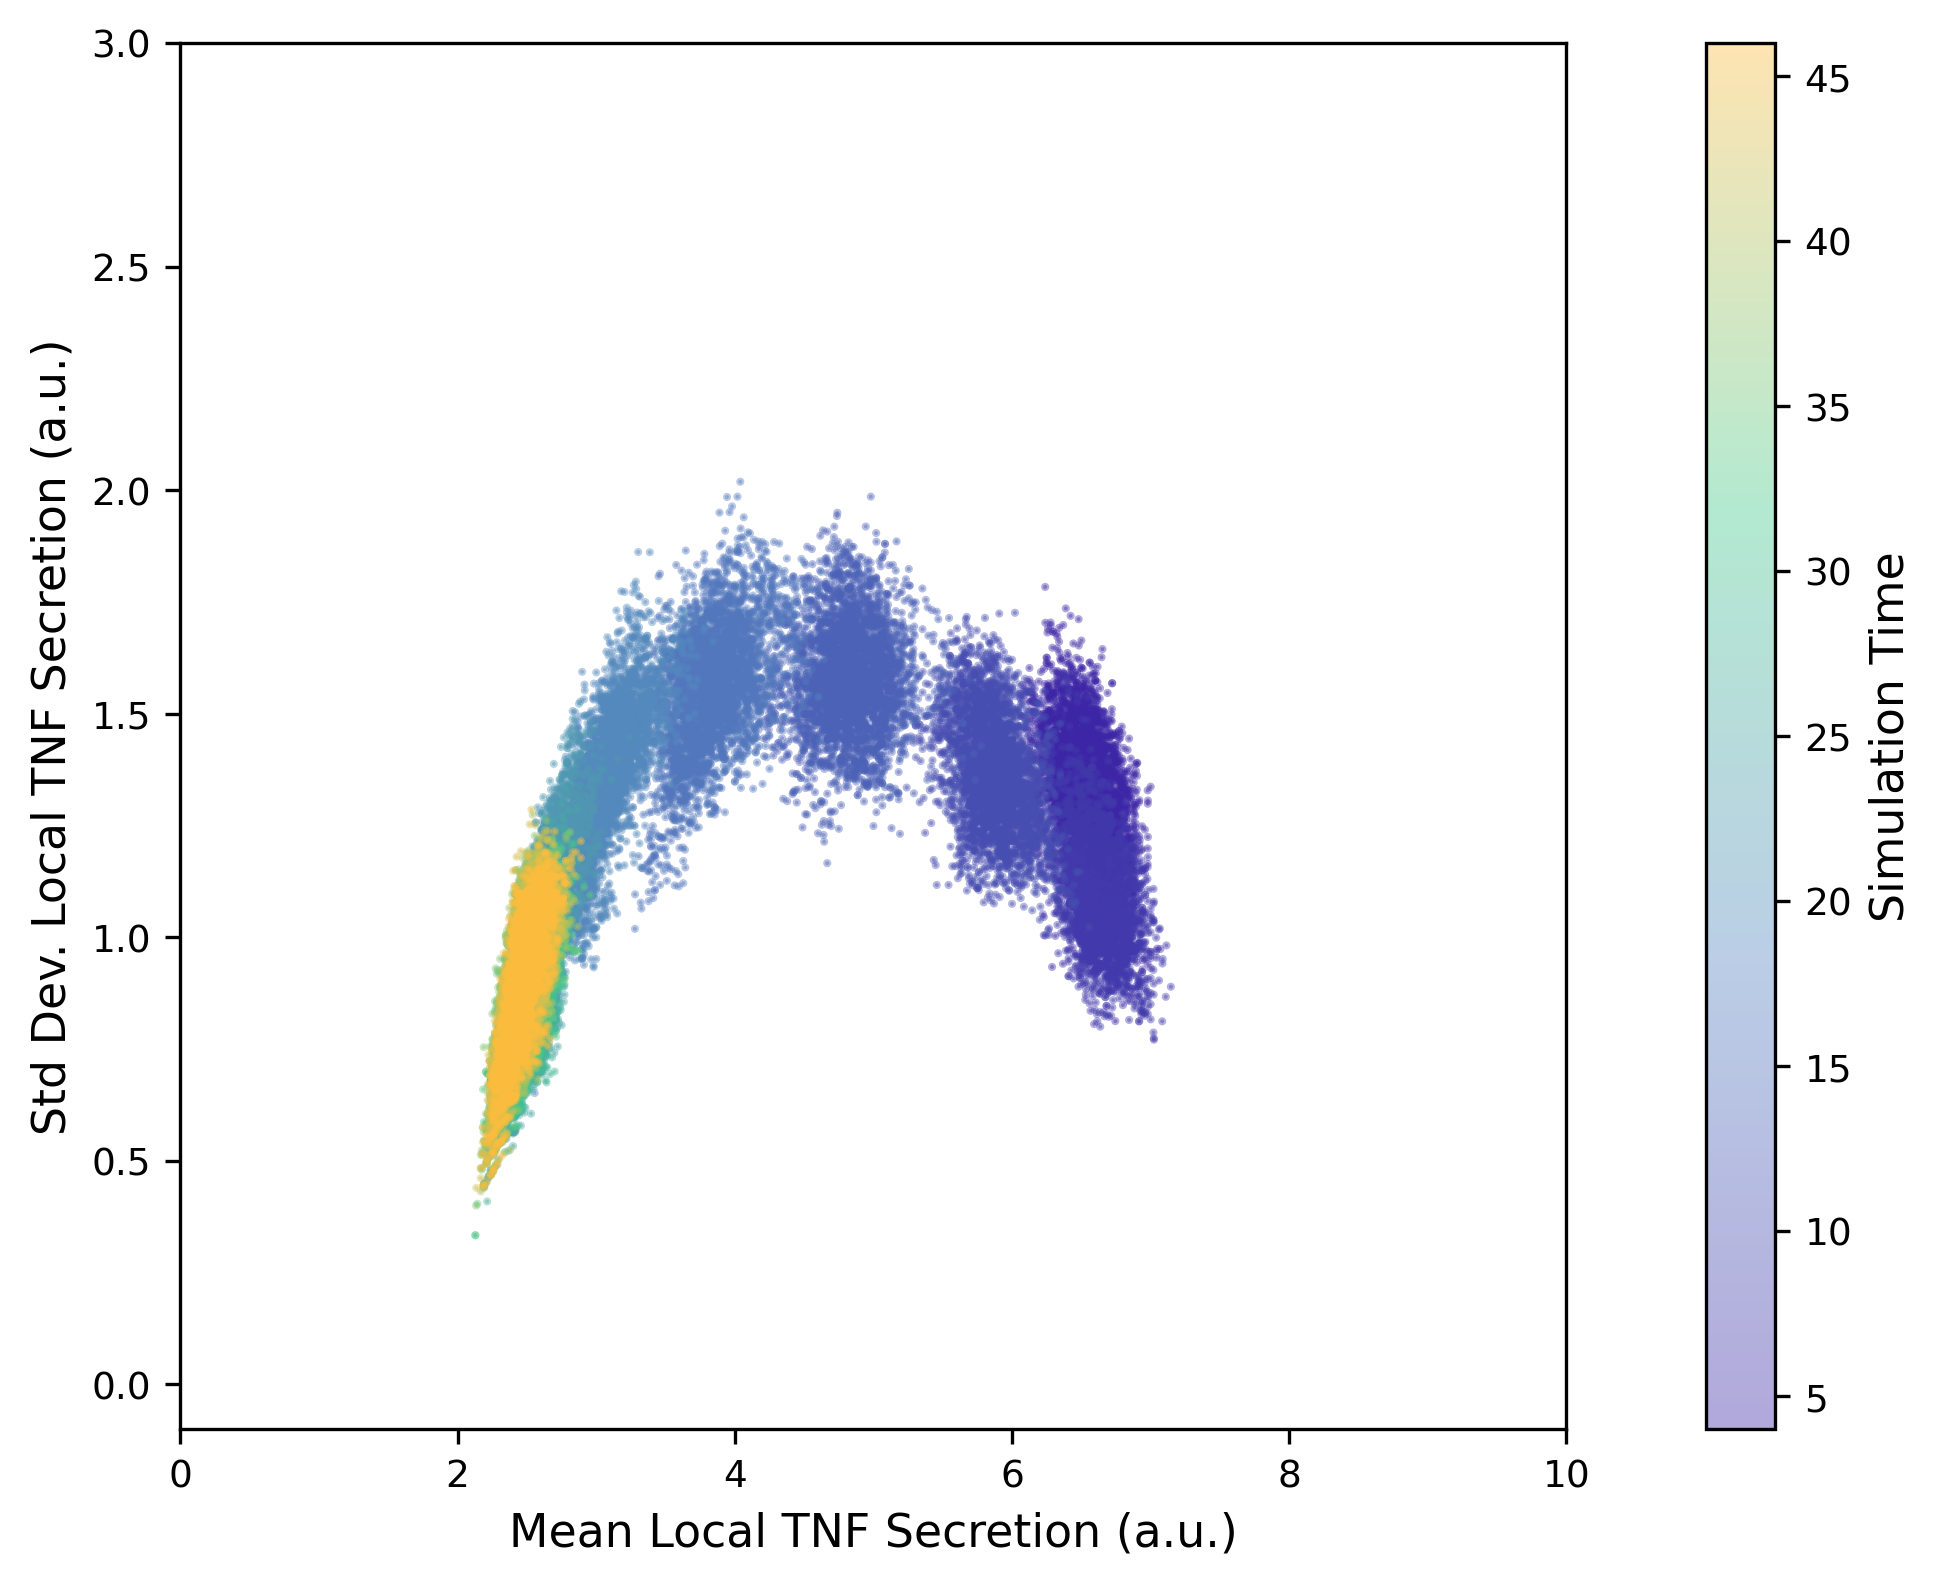

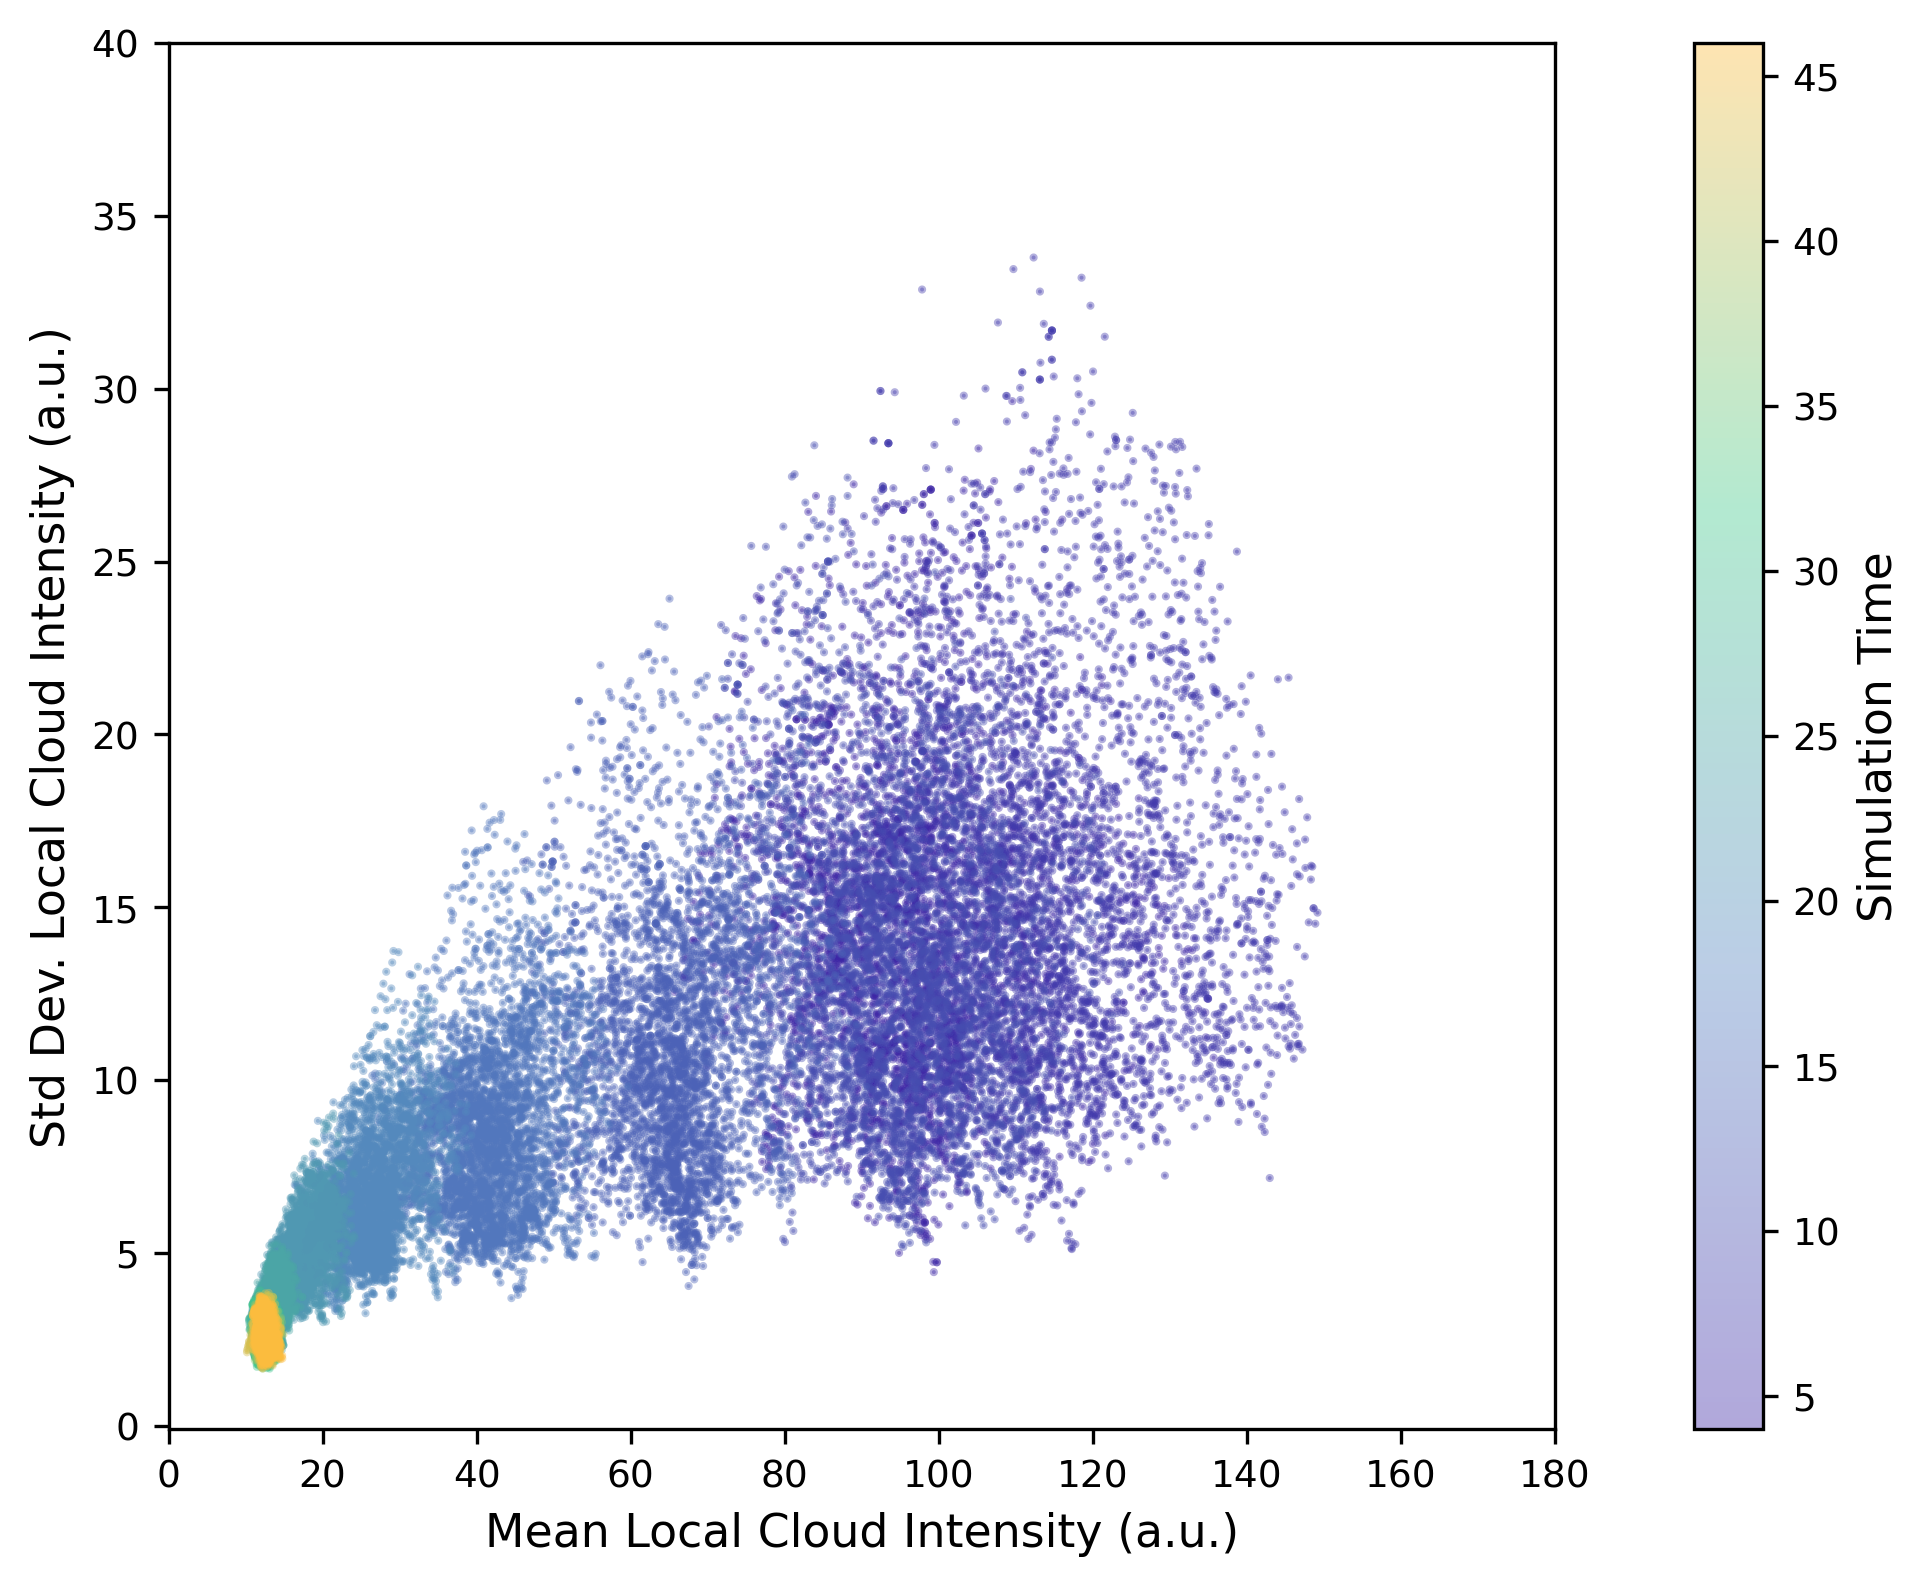

In [51]:
# select some densities to overlay on a single plot.
# strings must match how they occur in the filename.
timepoints_l = [x for x in range(4, 49, 3)]

cloud_overlay_fig = plot.figure(figsize=(12, 6), dpi=300)
levels_overlay_fig = plot.figure(figsize=(12, 6), dpi=300)
plot_local_trends("", cloud_overlay_fig, levels_overlay_fig, n_neighbors=40)
plot.figure(cloud_overlay_fig)
plot.savefig("cloud.png")
plot.figure(levels_overlay_fig)
plot.savefig("levels.png")

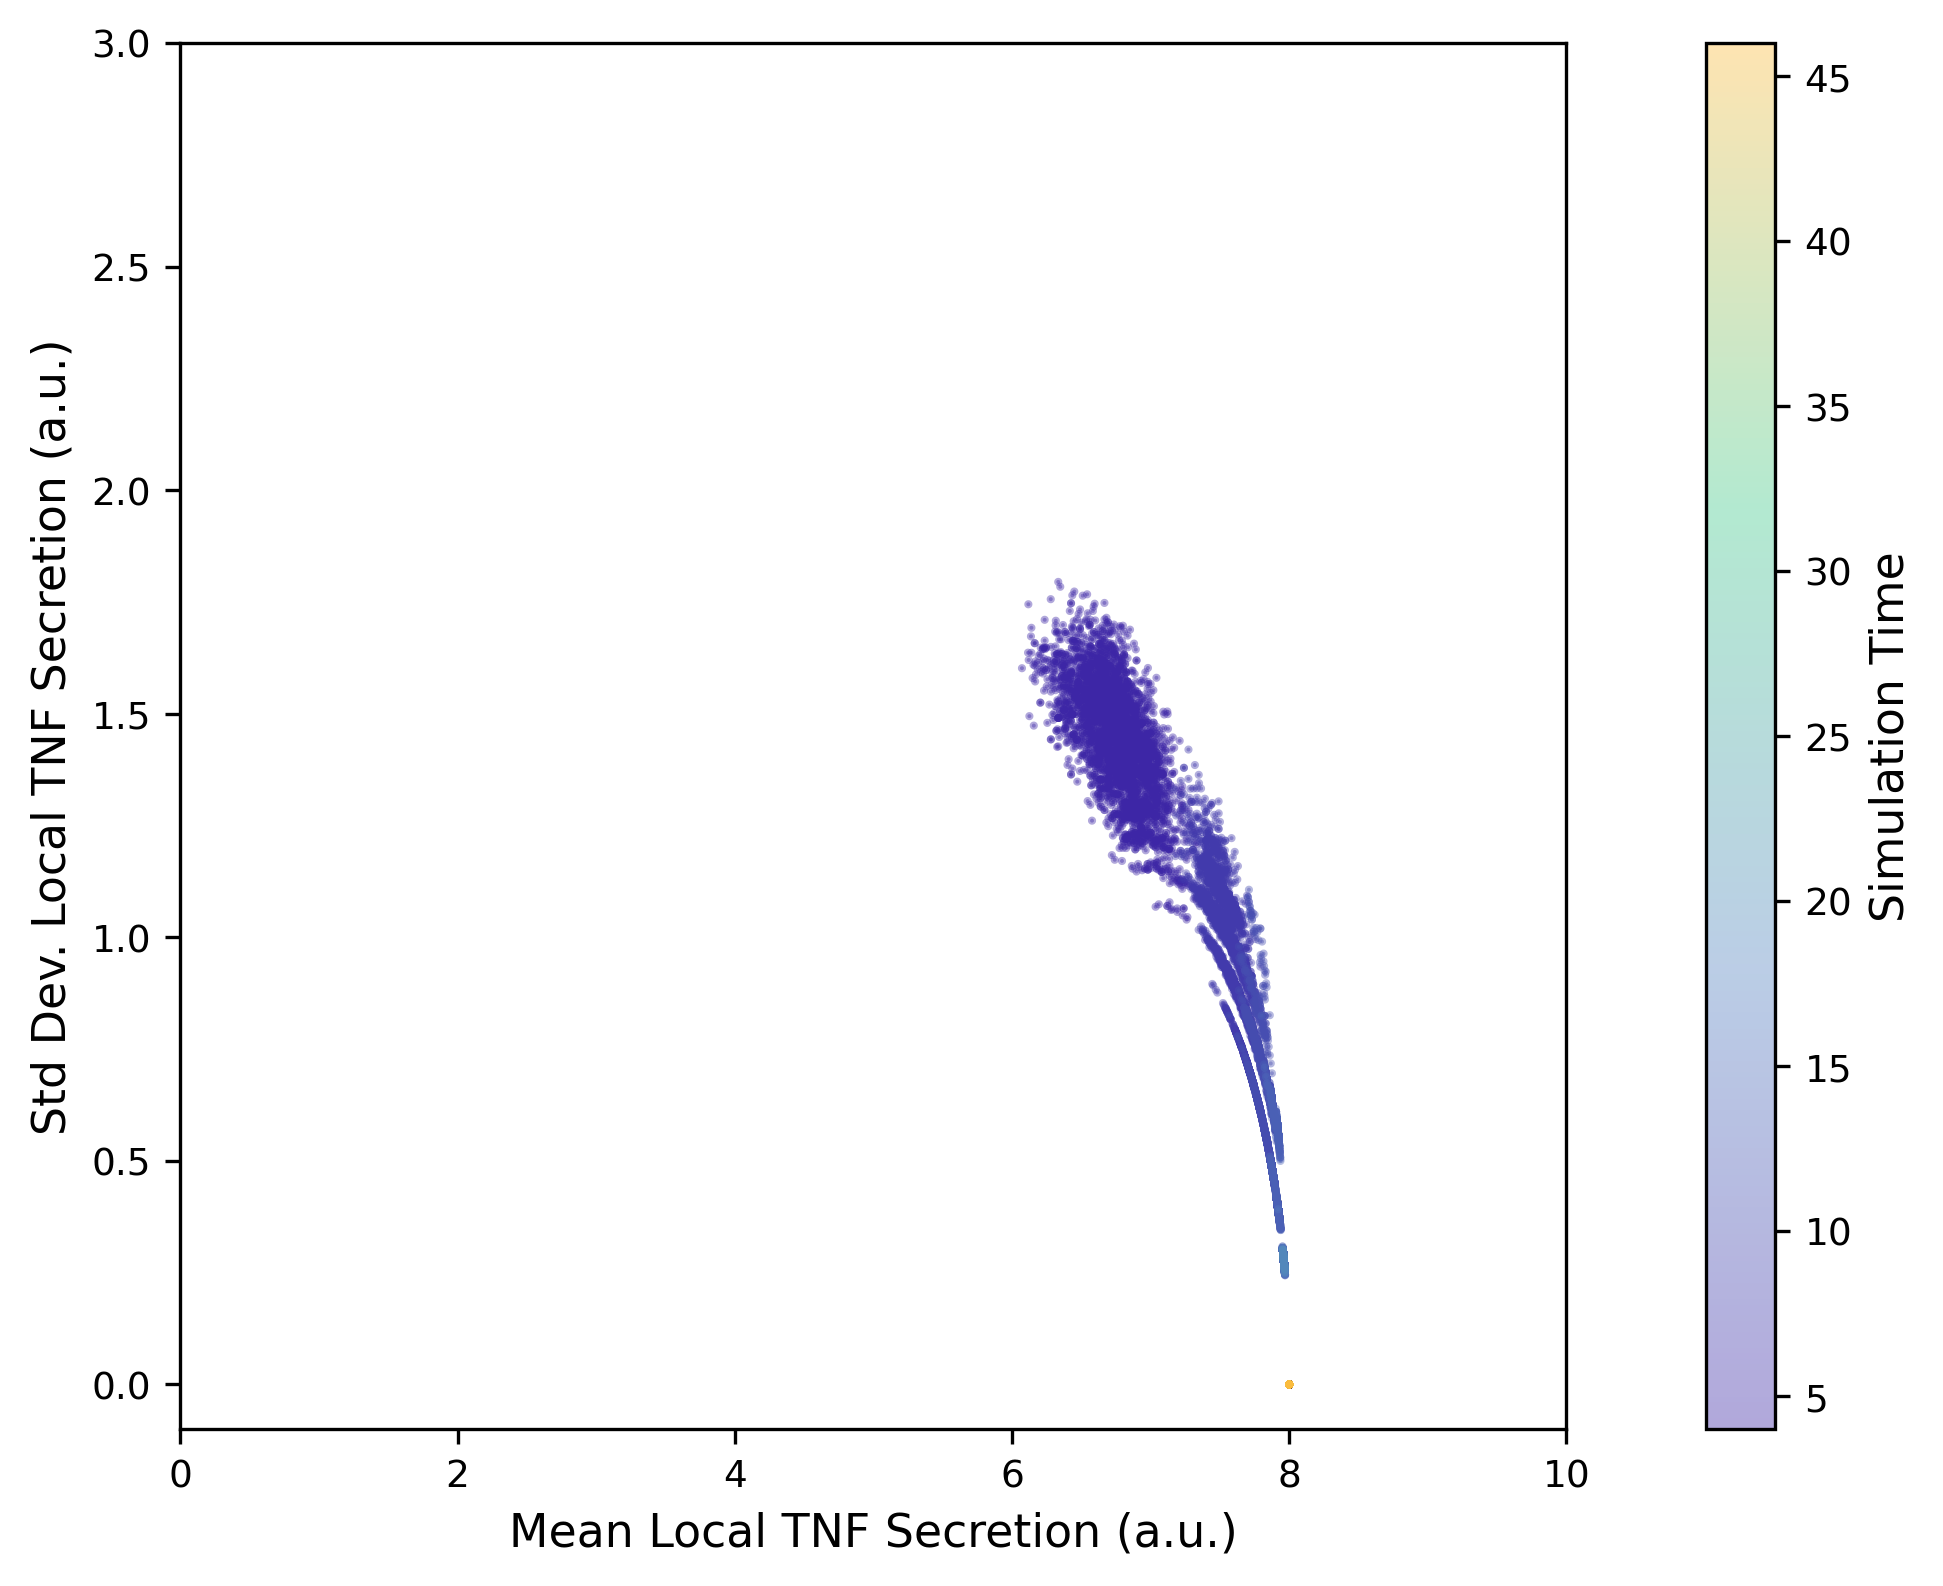

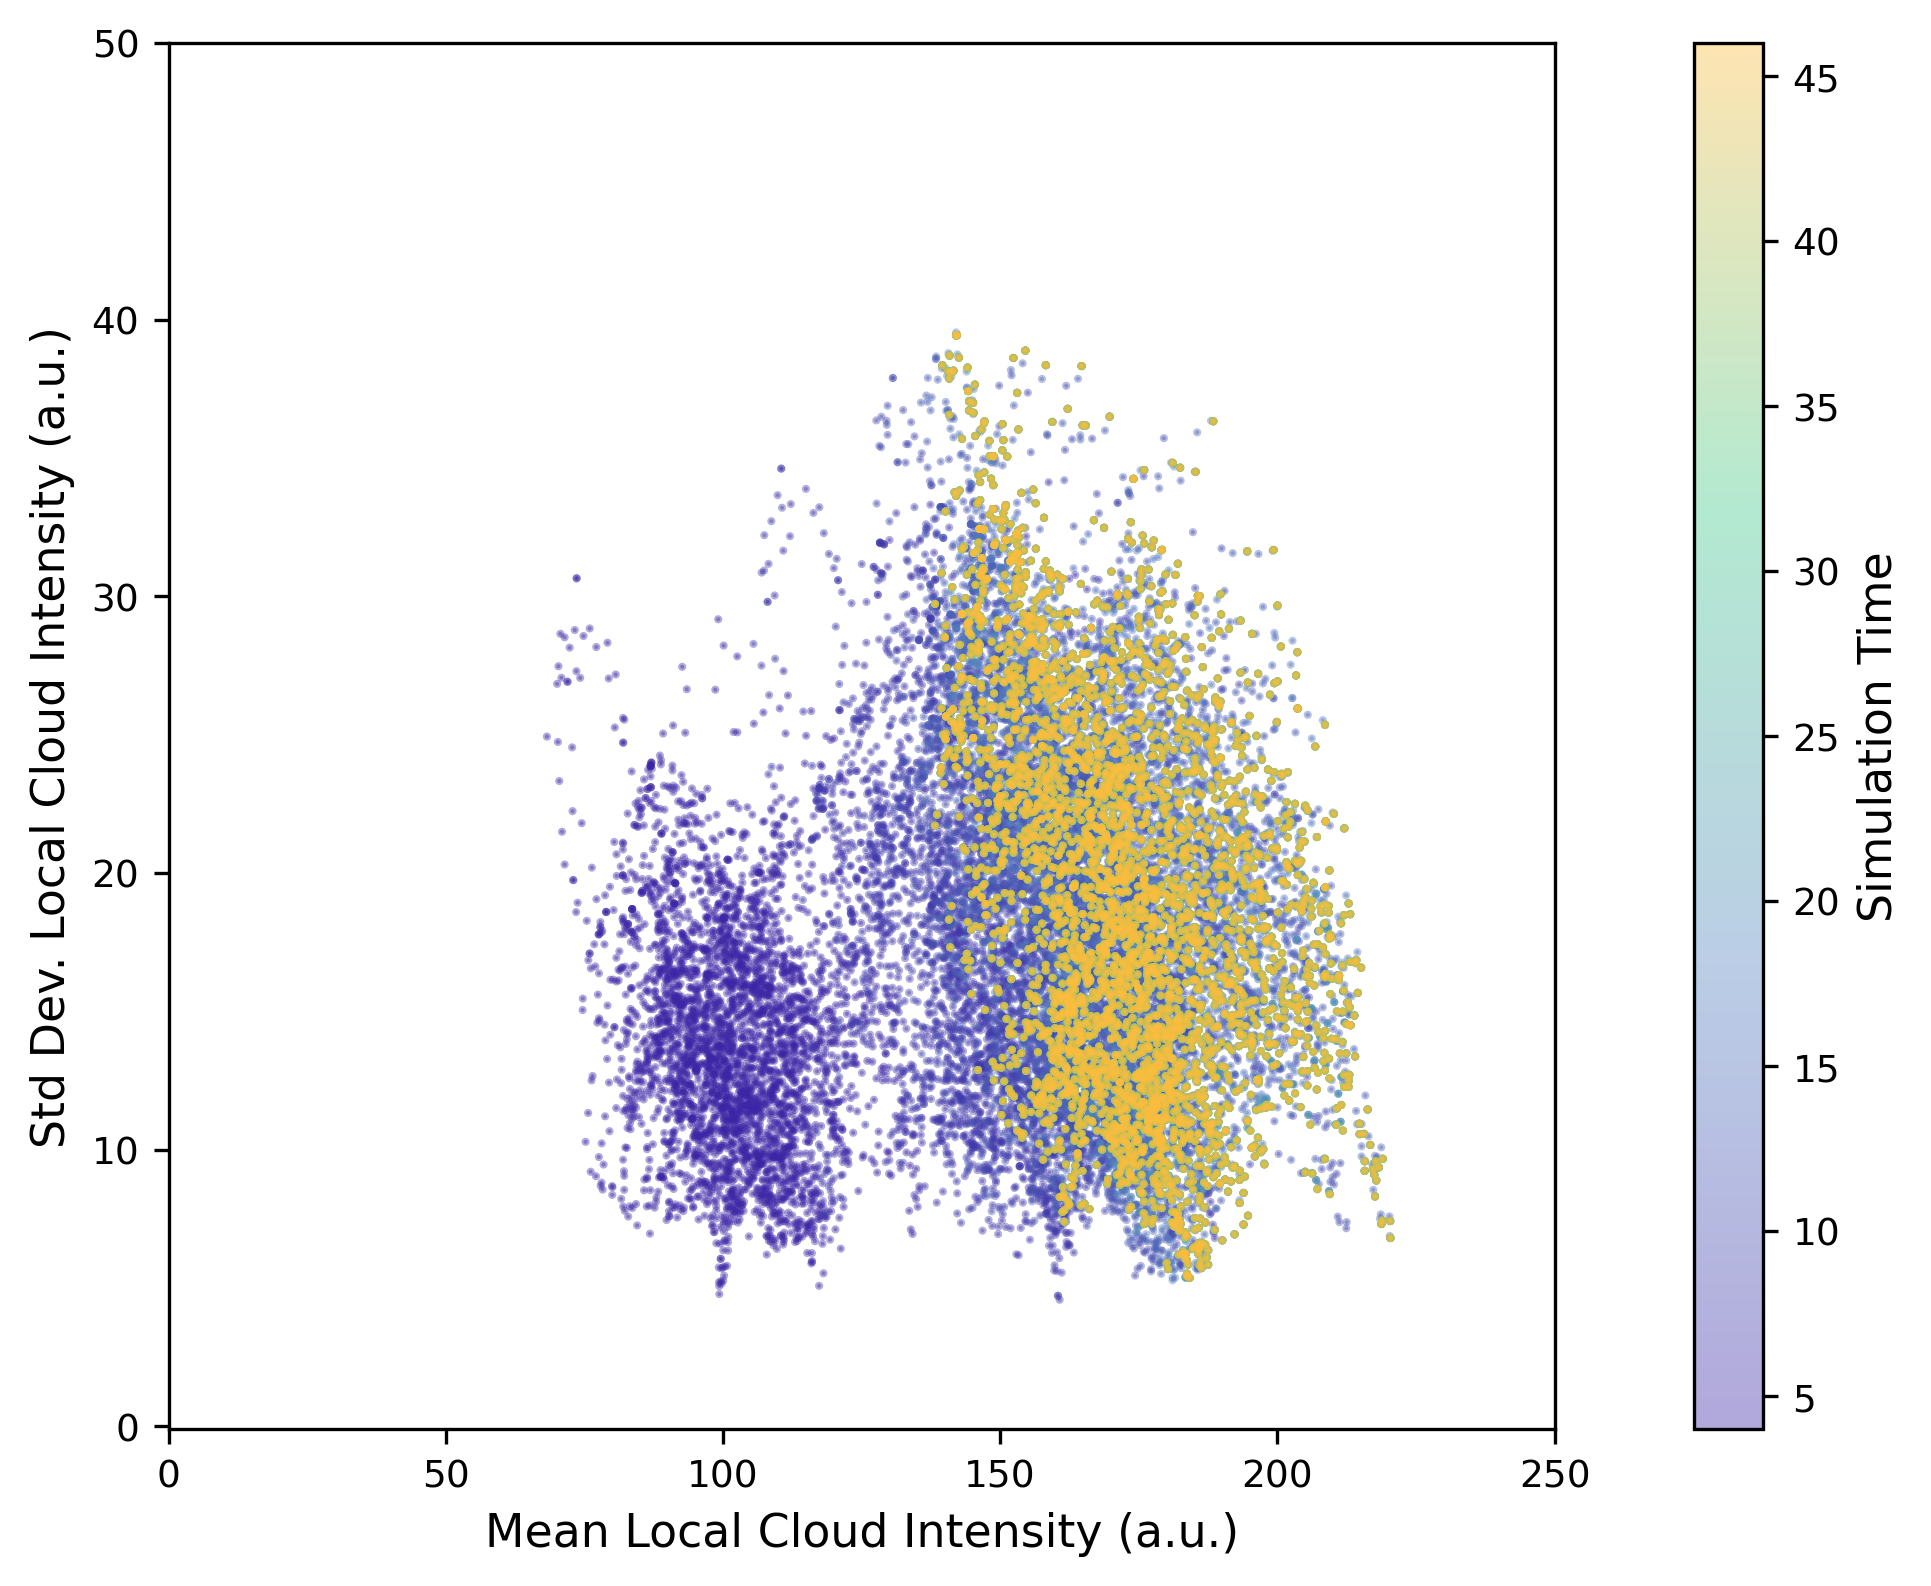

In [49]:
# select some densities to overlay on a single plot.
# strings must match how they occur in the filename.
timepoints_l = [x for x in range(4, 49, 3)]

cloud_overlay_fig = plot.figure(figsize=(12, 6), dpi=300)
levels_overlay_fig = plot.figure(figsize=(12, 6), dpi=300)
plot_local_trends("noneg", cloud_overlay_fig, levels_overlay_fig, n_neighbors=40)
plot.figure(cloud_overlay_fig)
plot.savefig("cloud.png")
plot.figure(levels_overlay_fig)
plot.savefig("levels.png")